In [2]:
import numpy as np
import time

PYTHON LIST VS NUMPY ARRAY

In [3]:
a = [i for i in range(10000000)]              #---> List comprehension
b = [i for i in range(10000000,20000000)]
c = []
start = time.time()
for i in range(len(a)):
    c.append(a[i]+b[i])
end = time.time()
time_taken = end-start
time_taken

1.8953635692596436

In [4]:
a = np.arange(10000000)
b = np.arange(10000000,20000000)
start = time.time()
c = a + b
end = time.time()
numpy_time = end-start
numpy_time

0.09221839904785156

In [5]:
time_taken/numpy_time

20.55298713520445

in this case numpy is 20 x faster than python list

Now lets see numpy vs pyhton list in terms of memory

In [6]:
a = [i for i in range(10000000)]
import sys
python_size = sys.getsizeof(a)
python_size

89095160

In [7]:
a = np.arange(10000000)
numpy_size = sys.getsizeof(a)
numpy_size

40000112

In [8]:
dif = python_size-numpy_size
dif

49095048

We can see that , numpy uses less memory as compares to python list

In [9]:
a = np.arange(0,12).reshape(4,3)
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11]])

Fancy Indexing

lets for above array a if we want to retrieve 1st,3rd and 4th row then it cannot be possible using normal indexing

In [10]:
#so where there is no any particular patterns then we use fancy indexing 
a[[0,2,3]]

array([[ 0,  1,  2],
       [ 6,  7,  8],
       [ 9, 10, 11]])

In [11]:
#lets do another example
a = np.arange(24).reshape(6,4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23]])

in the above array what if i want 1st,3rd,4th and last row

In [12]:
a[0,2,3,5]

IndexError: too many indices for array: array is 2-dimensional, but 4 were indexed

we might do as in above but as it is two dimensional this indexing wont work so we need fancy indexing

In [13]:
a[[0,2,3,5]] #---> passing list for indexing 

array([[ 0,  1,  2,  3],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [20, 21, 22, 23]])

in this what if i want only first,3rd and last colum then?

In [14]:
a[[0,2,3,5],[0,2,3]] 

IndexError: shape mismatch: indexing arrays could not be broadcast together with shapes (4,) (3,) 

we cant do like this instead we can do as :

In [16]:
selected_rows = a[[0,2,3,5]]
result = selected_rows[:,[0,2,3]]
result

array([[ 0,  2,  3],
       [ 8, 10, 11],
       [12, 14, 15],
       [20, 22, 23]])

## Boolean Indexing ##

till now we were retreiving data based on position, but sometimes we may need to retreive data according to some condition then we should use Boolean Indexing

In [18]:
#lets create an array
a = np.random.randint(1,100,24).reshape(6,4) #1 is inclusive , 100 is exclusive 24 is size of an array reshaping into 6 x 4 matrix
a

array([[32,  4, 76, 22],
       [33, 11, 68, 67],
       [48, 74, 87, 91],
       [19, 59, 44,  1],
       [64, 76, 39, 99],
       [61,  9, 60,  1]])

In [19]:
#find all numbers greater than 50
a>50             #--->> checks every array element and returns a boolean matrix

array([[False, False,  True, False],
       [False, False,  True,  True],
       [False,  True,  True,  True],
       [False,  True, False, False],
       [ True,  True, False,  True],
       [ True, False,  True, False]])

instead we can return the values which satifies this condition as :

In [20]:
a[a>50]

array([76, 68, 67, 74, 87, 91, 59, 64, 76, 99, 61, 60])

In [22]:
#find all the even numbers 
a[a % 2 == 0]

array([32,  4, 76, 22, 68, 48, 74, 44, 64, 76, 60])

In [29]:
#find all number greater than 50 and even
a[(a>50) & (a % 2 == 0)]  # & instead of 'and' because & is bitwise and for boolean value we should use that

array([76, 68, 74, 64, 76, 60])

## Broadcasting ##

this topic is very important

The term Broadcasting describes how numpy treats arrays with different shapes during arithmetic operations.
The smaller array is "broadcast" across larger array so that they have compatible shapes

In [2]:
# same shape
import numpy as np
a = np.arange(0,6).reshape(2,3)
b = np.arange(6,12).reshape(2,3)
print(a)
print(b)
print(a+b)

[[0 1 2]
 [3 4 5]]
[[ 6  7  8]
 [ 9 10 11]]
[[ 6  8 10]
 [12 14 16]]


This is fine , working perfectly

In [3]:
#different shape 
a = np.arange(0,6).reshape(2,3)
b = np.arange(3).reshape(1,3)
print(a)
print(b)

[[0 1 2]
 [3 4 5]]
[[0 1 2]]


the above array are of different shape , can addition be perfomed here? how?

In [4]:
print(a+b)

[[0 2 4]
 [3 5 7]]


here, addition is possible but how? here broadcasting comes into picture , one thing to note is that we do not do broadcasting , it hapens internally but we must be aware of when broadcasting happens and where broadcasting is not possible 

### Broadcasting Rules ###


1. **Matching Dimensions**: If two arrays have the same shape, operations are element-wise.

2. **Padding with Ones**: If shapes are different, the smaller array is left-padded with ones.

3. **Dimension Compatibility**: Two dimensions are compatible if:
   - They are equal, or  
   - One of them is `1`

4. **Expanding Dimensions**: If a dimension in one array is `1`, it expands to match the other array.

5. **Final Shape**: The resulting array shape is the maximum along each dimension.


### Broadcasting examples ###

In [5]:
A = np.array([[1, 2, 3], [4, 5, 6]])  # Shape (2,3)
B = np.array([[10, 20, 30]])          # Shape (1,3)
print(A + B)  # Broadcasting will happen as dimension is same and array B can be stretched to 2,3 from 1,3

[[11 22 33]
 [14 25 36]]


In [7]:
C = np.array([[10], [20]])           # Shape (2,1)
print(A+C)        #Broadcasting will happen as 2,1 can be stretched to 2,3

[[11 12 13]
 [24 25 26]]


In [8]:
E = np.array([10, 20])               # Shape (2,)
print(A + E) #error because shape (2,) can be made (1,2) and 1 can be stretched to 2 but it becomes (2,2) not (2,3)

ValueError: operands could not be broadcast together with shapes (2,3) (2,) 

## Working with Mathematical Formulas ##

how can we express complex mathematical formulas using numpy? this showcase the true power of numpy

![sigmoid](numpy_images/sigmoid.png)

In [9]:
#sigmoid function
#lets try to see how can we create a sigmoid function
def sigmoid(array):
    return 1/(1+np.exp(-array))

#lets try this function now 
arr = np.arange(0,10)
print(arr)
print(sigmoid(arr))

[0 1 2 3 4 5 6 7 8 9]
[0.5        0.73105858 0.88079708 0.95257413 0.98201379 0.99330715
 0.99752738 0.99908895 0.99966465 0.99987661]


### Mean square error ###
![mse](numpy_images/mse.png)

In [11]:
#lets try with this function
#first i will create a two array for actual output and prediction representing Y(i) and Y(i) bar
actual = np.array([2,4,6,7,8,9,10])
predicted = np.array([3,5,5,6,9,11,12])
def mse(actual,predict):
    return np.mean((actual-predict)**2)

mse(actual,predicted)

1.8571428571428572

### Cross-Entropy Loss (Log Loss) ###
![mse](numpy_images/cel.png)

In [12]:
#lets try a Cross-Entropy loss function
actual = np.array([2,4,6,7,8,9,10])
predicted = np.array([3,5,5,6,9,11,12])
def cross_entropy_loss(actual,predicted):
    return -(np.mean((actual*np.log(predicted)+(1-actual)*np.log(1-predicted))))

cross_entropy_loss(actual,predicted)

C:\Temp\ipykernel_4172\3789868821.py:5: RuntimeWarning: invalid value encountered in log
  return -(np.mean((actual*np.log(predicted)+(1-actual)*np.log(1-predicted))))


nan

In [13]:
#implementation is correct above but the array values should lies between 0 and 1 
actual = np.array([0, 1, 1, 0, 1, 1, 0])
predicted = np.array([0.1, 0.9, 0.8, 0.4, 0.7, 0.6, 0.2])
cross_entropy_loss(actual,predicted)

0.2907620464878265

### Working with missing values ###

here is how you deal with missing values using numpy 

In [14]:
#let me create an array with missing values as 
a = np.array([1,2,3,4,np.nan,6,7,8,np.nan,10,11,12])
a

array([ 1.,  2.,  3.,  4., nan,  6.,  7.,  8., nan, 10., 11., 12.])

In [16]:
# we can see there are 2 missing values in the array
np.isnan(a)  #this function tell all the values are you a missing value and returns boolean matrix

array([False, False, False, False,  True, False, False, False,  True,
       False, False, False])

In [17]:
# we can get missing value as 
a[np.isnan(a)]

array([nan, nan])

In [18]:
#now above array returns two missing values but i want non missing values i can do that as:
a[~(np.isnan(a))]   #~ means negetion

array([ 1.,  2.,  3.,  4.,  6.,  7.,  8., 10., 11., 12.])

this is how we can deal with missing values in numpy

### Plotting Graphs ###

In [20]:
import matplotlib.pyplot as plt

In [21]:
#lets create a one array as 
a = np.array([1,2,3,4,5,6,7,8,9])
b = sigmoid(a)
print(a)
print(b)

[1 2 3 4 5 6 7 8 9]
[0.73105858 0.88079708 0.95257413 0.98201379 0.99330715 0.99752738
 0.99908895 0.99966465 0.99987661]


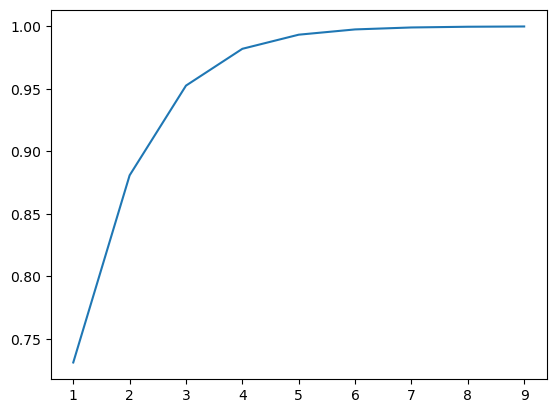

In [22]:
# now lets plot a graph
plt.plot(a,b)

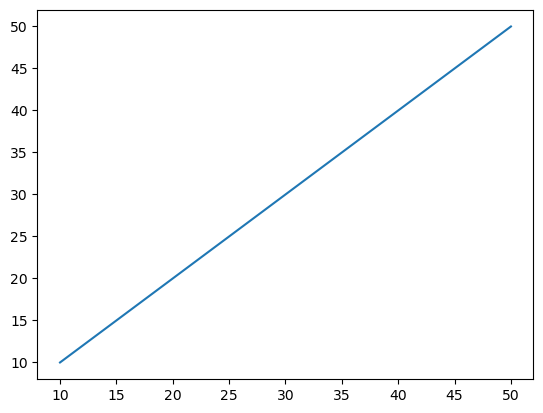

In [24]:
# lets draw a graph of straight line 
x = np.array([10,20,30,40,50])
y = x
plt.plot(x,y)

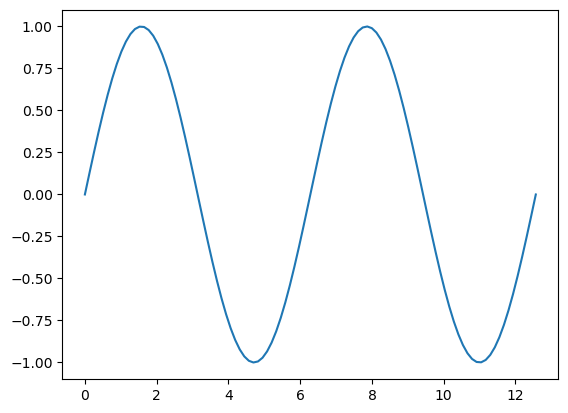

In [29]:
# now lets draw a sin function
x = np.linspace(0,4*np.pi,100)
y = np.sin(x)
plt.plot(x,y)

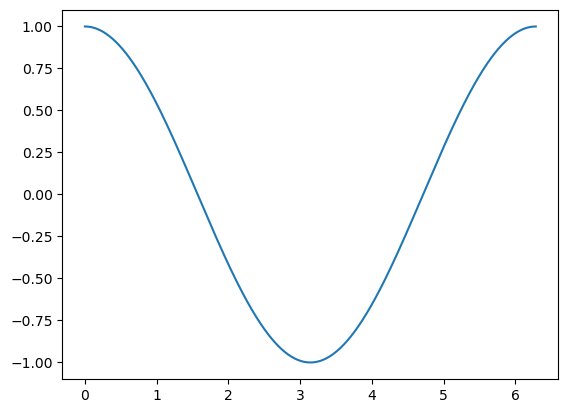

In [34]:
# lets draw for cos
x = np.linspace(0,2*np.pi,1000)
y = np.cos(x)
plt.plot(x,y)

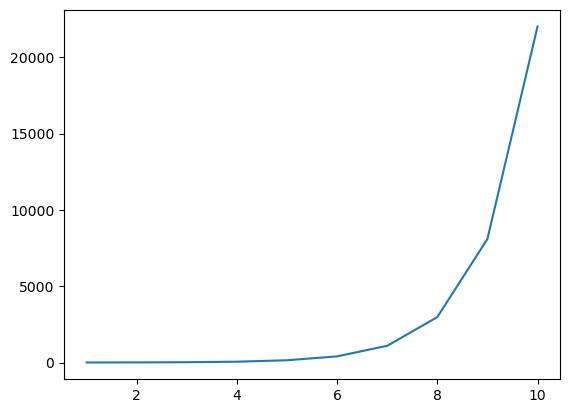

In [40]:
#let see the graph of exponential
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.exp(x)
plt.plot(x,y)

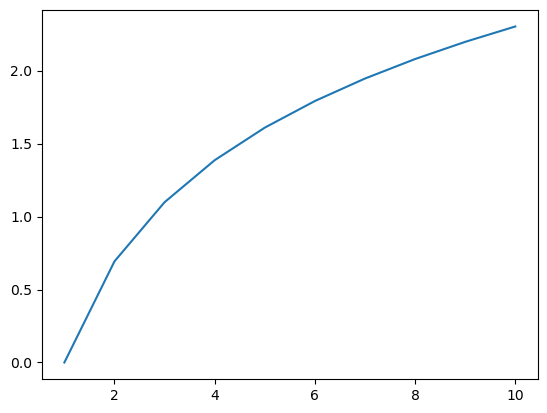

In [41]:
# lets see a log
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.log(x)
plt.plot(x,y)

Happy Coding !!